In [ ]:
import os
import requests


def download_nyc_taxi_data(year, month, output_dir="../data/incoming"):
    """Downloads NYC Yellow Taxi Trip Records for a specific year and month.

    :param year: int or str, e.g., 2026
    :param month: int or str, e.g., 1 or '01'
    :param output_dir: str, directory where the file will be saved
    """
    # Format month to be two digits (e.g., 1 -> '01')
    formatted_month = f"{int(month):02d}"
    filename = f"yellow_tripdata_{year}-{formatted_month}.parquet"

    # Base URL from TLC
    base_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    url = f"{base_url}{filename}"

    # Ensure output directory exists
    os.makedirs(output_dir, exist_ok=True)
    file_path = os.path.join(output_dir, filename)

    print(f"Downloading from: {url}")

    try:
        # Send a GET request to the URL
        response = requests.get(url, stream=True)

        # Check if the request was successful
        if response.status_code == 200:
            with open(file_path, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    if chunk:
                        f.write(chunk)
            print(f"Successfully downloaded and saved to: {file_path}")
        elif response.status_code == 404:
            print(
                f"Error 404: Data for {year}-{formatted_month} could not be found. "
                "Please verify that the year and month are correct and available."
            )
        else:
            print(
                f"Failed to download. HTTP Status Code: {response.status_code}"
            )

    except requests.exceptions.RequestException as e:
        print(f"An error occurred during transmission: {e}")




In [2]:
download_nyc_taxi_data(2026, 4)

Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2026-04.parquet


In [4]:
for year in range(2025, 2027):
    for month in range(1, 13):
        download_nyc_taxi_data(year, month)

Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-01.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-02.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-03.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-04.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-05.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-06.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-07.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-08.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-09.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-10.parquet
Successfully downloaded and saved to: ../data/incoming/yellow_tripdata_2025-11.parquet
Successfully downloaded and saved to: ../da

In [1]:
import os
from pyspark.sql import SparkSession

# Initialize Spark Session configured with the local catalog from local.yml
spark = (SparkSession.builder
    .appName("MedallionPlatformAuditor")
    .config("spark.sql.catalog.nyc", "org.apache.iceberg.spark.SparkCatalog")
    .config("spark.sql.catalog.nyc.type", "hadoop")
    .config("spark.sql.catalog.nyc.warehouse", "/opt/airflow/data/warehouse")
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions")
    .getOrCreate())

print("🔒 PySpark connected to Iceberg Catalog 'nyc'")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/08 22:25:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/07/08 22:25:55 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


🔒 PySpark connected to Iceberg Catalog 'nyc'


In [2]:
print("=== 1. BRONZE OPERATIONAL LEDGER ===")
# Convert to Pandas for clean HTML table rendering inside Jupyter
ledger_df = spark.sql("SELECT * FROM nyc.audit.ingestion_ledger ORDER BY finished_at DESC")
ledger_df.toPandas()['file_checksum'][1]

=== 1. BRONZE OPERATIONAL LEDGER ===


'b982ace703e3564d92e94edae5ec93515f4f1fb07a5b95e7404c32464c1a6a89'

In [10]:
print("=== 2. BRONZE RAW DATA SNAPSHOT ===")
bronze_df = spark.sql("""
    SELECT source_filename, source_year, source_month, ingestion_run_id, ingested_at_utc, count(*) as record_count
    FROM nyc.bronze.yellow_taxi_raw
    GROUP BY source_filename, source_year, source_month, ingestion_run_id, ingested_at_utc
    ORDER BY source_year, source_month
""")
bronze_df.toPandas()

=== 2. BRONZE RAW DATA SNAPSHOT ===


,source_filename,source_year,source_month,ingestion_run_id,ingested_at_utc,record_count
0,yellow_tripdata_2025-01.parquet,2025,1,asset_triggered__2026-07-08T22:27:57.798462+00...,2026-07-08 22:28:29.332353,3475226
1,yellow_tripdata_2025-02.parquet,2025,2,asset_triggered__2026-07-08T22:10:58.920652+00...,2026-07-08 22:11:49.594857,3577543
2,yellow_tripdata_2025-03.parquet,2025,3,asset_triggered__2026-07-08T22:16:56.644354+00...,2026-07-08 22:17:09.580737,4145257
3,yellow_tripdata_2025-04.parquet,2025,4,asset_triggered__2026-07-08T22:06:43.649560+00...,2026-07-08 22:06:50.925113,3970553
4,yellow_tripdata_2025-05.parquet,2025,5,asset_triggered__2026-07-08T22:15:36.453486+00...,2026-07-08 22:15:47.008444,4591845
5,yellow_tripdata_2025-06.parquet,2025,6,asset_triggered__2026-07-08T22:18:56.920612+00...,2026-07-08 22:19:22.691951,4322960
6,yellow_tripdata_2025-07.parquet,2025,7,asset_triggered__2026-07-08T22:19:37.103681+00...,2026-07-08 22:20:32.648658,3898963
7,yellow_tripdata_2025-08.parquet,2025,8,asset_triggered__2026-07-08T22:20:17.123987+00...,2026-07-08 22:22:03.851833,3574091
8,yellow_tripdata_2025-09.parquet,2025,9,asset_triggered__2026-07-08T22:21:37.815625+00...,2026-07-08 22:23:54.676306,4251015
9,yellow_tripdata_2025-10.parquet,2025,10,asset_triggered__2026-07-08T22:32:29.965546+00...,2026-07-08 22:32:46.487143,4428699


In [ ]:
print("=== 3A. SILVER PUBLISH LEDGER ===")
silver_ledger = spark.sql("SELECT * FROM nyc.audit.silver_publish_ledger ORDER BY verified_at DESC")
display(silver_ledger.toPandas())

print("\n=== 3B. SANITIZED SILVER VS QUARANTINED METRICS ===")
metrics_df = spark.sql("""
    SELECT
        'nyc.silver.yellow_taxi_trips' as table_name,
        ingestion_run_id,
        count(*) as row_count
    FROM nyc.silver.yellow_taxi_trips
    GROUP BY ingestion_run_id

    UNION ALL

    SELECT
        'nyc.quarantine.yellow_taxi_trips' as table_name,
        ingestion_run_id,
        count(*) as row_count
    FROM nyc.quarantine.yellow_taxi_trips
    GROUP BY ingestion_run_id
""")
metrics_df.toPandas()

=== 3A. SILVER PUBLISH LEDGER ===


,ingestion_run_id,source_filename,status,verified_at
0,asset_triggered__2026-07-01T22:53:12.211194+00...,yellow_tripdata_2026-03.parquet,SUCCESS,2026-07-01 22:53:40.713827
1,asset_triggered__2026-07-01T22:25:11.741237+00...,yellow_tripdata_2026-05.parquet,SUCCESS,2026-07-01 22:25:40.323082



=== 3B. SANITIZED SILVER VS QUARANTINED METRICS ===


,table_name,ingestion_run_id,row_count
0,nyc.silver.yellow_taxi_trips,asset_triggered__2026-07-01T22:53:12.211194+00...,2881539
1,nyc.silver.yellow_taxi_trips,asset_triggered__2026-07-01T22:25:11.741237+00...,3012401
2,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:24:11.304874+00...,917088
3,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:25:11.741237+00...,1078435
4,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:53:12.211194+00...,1070912


In [ ]:
print("=== 3A. SILVER PUBLISH LEDGER ===")
silver_ledger = spark.sql("SELECT * FROM nyc.audit.silver_publish_ledger ORDER BY verified_at DESC")
display(silver_ledger.toPandas())

print("\n=== 3B. SANITIZED SILVER VS QUARANTINED METRICS ===")
metrics_df = spark.sql("""
    SELECT
        'nyc.silver.yellow_taxi_trips' as table_name,
        ingestion_run_id,
        count(*) as row_count
    FROM nyc.silver.yellow_taxi_trips
    GROUP BY ingestion_run_id

    UNION ALL

    SELECT
        'nyc.quarantine.yellow_taxi_trips' as table_name,
        ingestion_run_id,
        count(*) as row_count
    FROM nyc.quarantine.yellow_taxi_trips
    GROUP BY ingestion_run_id
""")
metrics_df.toPandas()

=== 3A. SILVER PUBLISH LEDGER ===


,ingestion_run_id,source_filename,status,verified_at
0,asset_triggered__2026-07-01T23:13:03.108519+00...,yellow_tripdata_2026-04.parquet,SUCCESS,2026-07-01 23:13:32.163029
1,asset_triggered__2026-07-01T22:53:12.211194+00...,yellow_tripdata_2026-03.parquet,SUCCESS,2026-07-01 22:53:40.713827
2,asset_triggered__2026-07-01T22:25:11.741237+00...,yellow_tripdata_2026-05.parquet,SUCCESS,2026-07-01 22:25:40.323082



=== 3B. SANITIZED SILVER VS QUARANTINED METRICS ===


,table_name,ingestion_run_id,row_count
0,nyc.silver.yellow_taxi_trips,asset_triggered__2026-07-01T23:13:03.108519+00...,2914258
1,nyc.silver.yellow_taxi_trips,asset_triggered__2026-07-01T22:53:12.211194+00...,2881539
2,nyc.silver.yellow_taxi_trips,asset_triggered__2026-07-01T22:25:11.741237+00...,3012401
3,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:53:12.211194+00...,1070912
4,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:24:11.304874+00...,917088
5,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T22:25:11.741237+00...,1078435
6,nyc.quarantine.yellow_taxi_trips,asset_triggered__2026-07-01T23:13:03.108519+00...,916982


In [10]:
print("=== 4A. ICEBERG TRANSACTION HISTORY ===")
history_df = spark.sql("SELECT * FROM nyc.silver.yellow_taxi_trips.history")
display(history_df.toPandas())

print("\n=== 4B. TABLE SNAPSHOT EVOLUTION ===")
snapshots_df = spark.sql("SELECT snapshot_id, parent_id, operation, summary FROM nyc.silver.yellow_taxi_trips.snapshots")
display(snapshots_df.toPandas())

print("\n=== 4C. PHYSICAL PARQUET LAYOUT AND RECORD SIZES ===")
# Corrected 'file_size_bytes' to 'file_size_in_bytes'
files_df = spark.sql("SELECT file_path, record_count, file_size_in_bytes FROM nyc.silver.yellow_taxi_trips.files")
# files_df.show(vertical=True, truncate=False)
display(files_df.toPandas())

=== 4A. ICEBERG TRANSACTION HISTORY ===


,made_current_at,snapshot_id,parent_id,is_current_ancestor
0,2026-07-01 22:13:27.068,4137318236666507804,NaN,True



=== 4B. TABLE SNAPSHOT EVOLUTION ===


,snapshot_id,parent_id,operation,summary
0,4137318236666507804,NaN,append,"{'engine-version': '3.5.6', 'added-data-files'..."



=== 4C. PHYSICAL PARQUET LAYOUT AND RECORD SIZES ===


,file_path,record_count,file_size_in_bytes
0,/opt/airflow/data/warehouse/silver/yellow_taxi...,110103,1467356
1,/opt/airflow/data/warehouse/silver/yellow_taxi...,100364,1384796
2,/opt/airflow/data/warehouse/silver/yellow_taxi...,83845,1201225
3,/opt/airflow/data/warehouse/silver/yellow_taxi...,99092,1347927
4,/opt/airflow/data/warehouse/silver/yellow_taxi...,111055,1485961
5,/opt/airflow/data/warehouse/silver/yellow_taxi...,107091,1434574
6,/opt/airflow/data/warehouse/silver/yellow_taxi...,78507,1135848
7,/opt/airflow/data/warehouse/silver/yellow_taxi...,97414,1327461
8,/opt/airflow/data/warehouse/silver/yellow_taxi...,104555,1424186
9,/opt/airflow/data/warehouse/silver/yellow_taxi...,101076,1388896


In [ ]:
print("=== 5. GOLD BI HOURLY FLEET UTILIZATION ===")
gold_bi = spark.sql("""
    SELECT target_year, target_month, pickup_hour_ts, pickup_location_id, trip_count, avg_distance
    FROM nyc.gold.hourly_fleet_utilization
    ORDER BY trip_count DESC
    LIMIT 10
""")
gold_bi.toPandas()

=== 5. GOLD BI HOURLY FLEET UTILIZATION ===


,target_year,target_month,pickup_hour_ts,pickup_location_id,trip_count,avg_distance
0,2026,4,2026-04-08 18:00:00,161,779,2.019487
1,2026,4,2026-04-07 18:00:00,161,632,1.891835
2,2026,4,2026-04-09 18:00:00,161,624,1.889439
3,2026,4,2026-04-29 18:00:00,161,622,1.990707
4,2026,4,2026-04-21 18:00:00,161,620,1.839565
5,2026,4,2026-04-29 19:00:00,161,615,2.016537
6,2026,4,2026-04-16 17:00:00,161,601,1.972912
7,2026,4,2026-04-15 17:00:00,161,599,2.168030
8,2026,4,2026-04-30 17:00:00,161,586,2.010887
9,2026,4,2026-04-21 19:00:00,161,586,2.131792


In [ ]:
print("=== 6A. GOLD ML OBSERVED FEATURE GRID ===")
gold_ml = spark.sql("""
    SELECT target_year, target_month, pickup_location_id, pickup_hour_ts, ride_count
    FROM nyc.gold.hourly_ml_observations
    ORDER BY pickup_hour_ts DESC, pickup_location_id DESC
    LIMIT 10
""")
display(gold_ml.toPandas())

print("\n=== 6B. ML DATA LEAKAGE COMPLIANCE AUDIT ===")
forbidden_fields = ["dropoff_datetime", "tip_amount", "fare_amount", "passenger_count", "trip_distance"]
actual_columns = spark.table("nyc.gold.hourly_ml_observations").columns

leaked = [f for f in forbidden_fields if f in actual_columns]
if not leaked:
    print("✅ Audit Passed: Zero target leakage features found in your ML Serving Layer table structure.")
else:
    print(f"❌ Target Leakage Breach: Forbidden fields detected: {leaked}")

=== 6A. GOLD ML OBSERVED FEATURE GRID ===


,target_year,target_month,pickup_location_id,pickup_hour_ts,ride_count
0,2026,4,263,2026-04-30 23:00:00,43
1,2026,4,262,2026-04-30 23:00:00,17
2,2026,4,261,2026-04-30 23:00:00,15
3,2026,4,260,2026-04-30 23:00:00,0
4,2026,4,259,2026-04-30 23:00:00,0
5,2026,4,258,2026-04-30 23:00:00,0
6,2026,4,257,2026-04-30 23:00:00,0
7,2026,4,256,2026-04-30 23:00:00,2
8,2026,4,255,2026-04-30 23:00:00,4
9,2026,4,254,2026-04-30 23:00:00,0



=== 6B. ML DATA LEAKAGE COMPLIANCE AUDIT ===
✅ Audit Passed: Zero target leakage features found in your ML Serving Layer table structure.


In [13]:
!pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 51.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 14.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 15.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [seaborn]m5/7 [matplotlib]


📊 Querying Gold BI Table and compiling visualization metrics...
📊 Generating Chart 2: Cumulative monthly data growth...


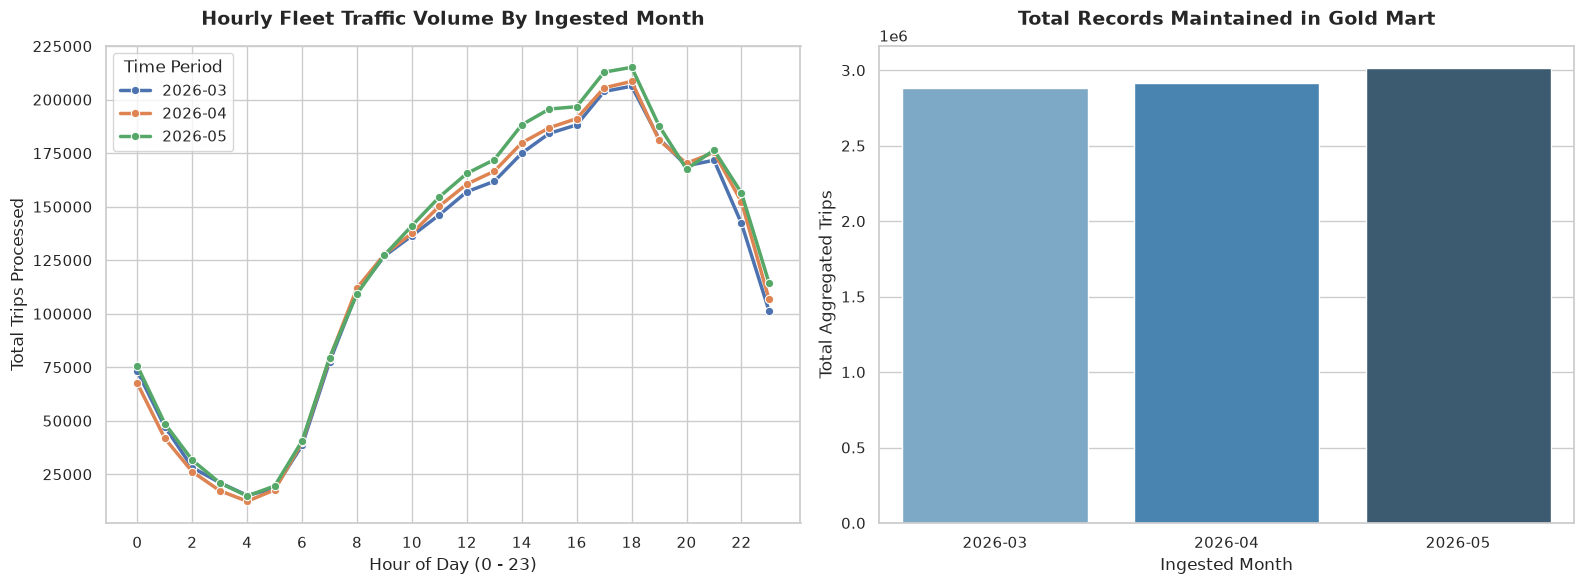

In [ ]:
# --- JUPYTER VISUALIZATION CELL ---
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Querying Gold BI Table and compiling visualization metrics...")

# 1. Pull the data from our Gold reporting layer and aggregate to a notebook-safe size
hourly_trends_df = spark.sql("""
    SELECT
        target_year,
        target_month,
        hour(pickup_hour_ts) as hour_of_day,
        sum(trip_count) as total_trips,
        avg(avg_distance) as monthly_avg_distance
    FROM nyc.gold.hourly_fleet_utilization
    GROUP BY 1, 2, 3
    ORDER BY target_year, target_month, hour_of_day
""").toPandas()

# Create a clean string label for grouping multiple months together in the legend
hourly_trends_df['Time Period'] = hourly_trends_df['target_year'].astype(str) + "-" + hourly_trends_df['target_month'].astype(str).str.zfill(2)

# 2. Set up the plotting canvas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- PLOT 1: Hourly Fleet Traffic Volume Over Distinct Ingested Months ---
sns.lineplot(
    data=hourly_trends_df,
    x="hour_of_day",
    y="total_trips",
    hue="Time Period",
    marker="o",
    linewidth=2.5,
    ax=ax1
)
ax1.set_title("Hourly Fleet Traffic Volume By Ingested Month", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Hour of Day (0 - 23)", fontsize=12)
ax1.set_ylabel("Total Trips Processed", fontsize=12)
ax1.set_xticks(range(0, 24, 2))

# --- PLOT 2: Cumulative Total Growth Matrix (Proving Data Accumulation) ---
print("📊 Generating Chart 2: Cumulative monthly data growth...")
monthly_totals = hourly_trends_df.groupby("Time Period")["total_trips"].sum().reset_index()

# Explicitly mapped hue to Time Period and disabled the redundant legend box
sns.barplot(
    data=monthly_totals,
    x="Time Period",
    y="total_trips",
    hue="Time Period",
    palette="Blues_d",
    legend=False,
    ax=ax2
)
ax2.set_title("Total Records Maintained in Gold Mart", fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel("Ingested Month", fontsize=12)
ax2.set_ylabel("Total Aggregated Trips", fontsize=12)

# Ensure clean layout borders
plt.tight_layout()
plt.show()

In [ ]:
print("=== EXPERIMENT STEP 1: RECORD BASELINE (BEFORE) ===")

# 1. Get the baseline total row count
before_count = spark.sql("SELECT COUNT(*) FROM nyc.gold.hourly_fleet_utilization").collect()[0][0]
print(f"📊 Baseline Total Rows: {before_count}")

# 2. Extract a small deterministic fingerprint sample to compare later
baseline_fingerprint = spark.sql("""
    SELECT pickup_hour_ts, pickup_location_id, trip_count, avg_distance
    FROM nyc.gold.hourly_fleet_utilization
    ORDER BY pickup_hour_ts ASC, pickup_location_id ASC
    LIMIT 5
""").toPandas()

display(baseline_fingerprint)

=== EXPERIMENT STEP 1: RECORD BASELINE (BEFORE) ===
📊 Baseline Total Rows: 384198


,pickup_hour_ts,pickup_location_id,trip_count,avg_distance
0,2026-03-01,4,77,0.0
1,2026-03-01,7,2,0.0
2,2026-03-01,13,5,0.0
3,2026-03-01,24,2,0.0
4,2026-03-01,25,1,0.0


In [ ]:
print("=== EXPERIMENT STEP 2: FORCING COLD COMPUTE RUN ===")

from pyspark.sql.functions import col, lit, date_trunc

# 1. Read directly from Silver to bypass Airflow controls
silver_data = spark.table("nyc.silver.yellow_taxi_trips")

# 2. Extract the targets for deletion from your source data dynamically
# (For April 2026, this resolves to target_year=2026 and target_month=4)
distinct_months = silver_data.select("source_year", "source_month").distinct().collect()

if distinct_months:
    for row in distinct_months:
        year_val = row["source_year"]
        month_val = row["source_month"]

        print(f"🧹 Clearing target data slice: year={year_val}, month={month_val}")
        # 🎯 MATCHING PRODUCTION: Explicitly delete the old rows first
        spark.sql(f"""
            DELETE FROM nyc.gold.hourly_fleet_utilization
            WHERE target_year = {year_val} AND target_month = {month_val}
        """)

# 3. Perform the exact production granularity transformation (Hourly)
aggregated_gold = (silver_data
    .groupBy(
        col("source_year").alias("target_year"),
        col("source_month").alias("target_month"),
        date_trunc('hour', col("pickup_datetime")).alias("pickup_hour_ts"),
        col("pickup_location_id")
    )
    .count()
    .withColumnRenamed("count", "trip_count")
    .withColumn("avg_distance", lit(0.0))
)

# 4. Align the arity columns to match the target table schema exactly
final_gold_payload = aggregated_gold.select(
    "target_year", "target_month", "pickup_hour_ts",
    "pickup_location_id", "trip_count", "avg_distance"
)

# 5. Execute a standard append now that the old data slice has been purged
final_gold_payload.write.format("iceberg").mode("append").save("nyc.gold.hourly_fleet_utilization")

print("✅ Force run complete. Gold slice safely isolated, deleted, and re-appended.")

=== EXPERIMENT STEP 2: FORCING COLD COMPUTE RUN ===
🧹 Clearing target data slice: year=2026, month=5
🧹 Clearing target data slice: year=2026, month=3
✅ Force run complete. Gold slice safely isolated, deleted, and re-appended.


In [ ]:
print("=== EXPERIMENT STEP 3: AUDIT AND VERIFY INVARIANTS (AFTER) ===")

# 1. Fetch the post-execution row count
after_count = spark.sql("SELECT COUNT(*) FROM nyc.gold.hourly_fleet_utilization").collect()[0][0]
print(f"📊 Post-Run Total Rows: {after_count}")

# 2. Assert that row volumes remained completely unchanged
if before_count == after_count:
    print("✅ IDEMPOTENCY SUCCESS: Before and After row counts match exactly!")
else:
    print(f"❌ STATE BREACH: Row count expanded from {before_count} to {after_count}")

# 3. Pull the identical metrics fingerprint slice for validation
post_fingerprint = spark.sql("""
    SELECT pickup_hour_ts, pickup_location_id, trip_count, avg_distance
    FROM nyc.gold.hourly_fleet_utilization
    ORDER BY pickup_hour_ts ASC, pickup_location_id ASC
    LIMIT 5
""").toPandas()

print("\n🔍 Comparing Baseline Data to Post-Run Data Side-by-Side:")
display(post_fingerprint)

=== EXPERIMENT STEP 3: AUDIT AND VERIFY INVARIANTS (AFTER) ===
📊 Post-Run Total Rows: 384198
✅ IDEMPOTENCY SUCCESS: Before and After row counts match exactly!

🔍 Comparing Baseline Data to Post-Run Data Side-by-Side:


,pickup_hour_ts,pickup_location_id,trip_count,avg_distance
0,2026-03-01,4,77,0.0
1,2026-03-01,7,2,0.0
2,2026-03-01,13,5,0.0
3,2026-03-01,24,2,0.0
4,2026-03-01,25,1,0.0


In [ ]:
print("🧹 Purging pipeline ledger boundaries for April 2026...")

# 1. Clear out the Bronze operational file-ingestion tracking record
spark.sql("""
    DELETE FROM nyc.audit.ingestion_ledger
    WHERE source_filename = 'yellow_tripdata_2026-04.parquet'
""")

# 2. Clear out the Silver purification execution ledger record
spark.sql("""
    DELETE FROM nyc.audit.silver_publish_ledger
    WHERE source_filename = 'yellow_tripdata_2026-04.parquet'
""")

# 3. Clear out the actual data slices from Bronze and Silver so they can be re-written
spark.sql("DELETE FROM nyc.bronze.yellow_taxi_raw WHERE source_year = 2026 AND source_month = 4")
spark.sql("DELETE FROM nyc.silver.yellow_taxi_trips WHERE source_year = 2026 AND source_month = 4")
spark.sql("DELETE FROM nyc.gold.hourly_fleet_utilization WHERE target_year = 2026 AND target_month = 4")


print("🟢 Ledgers reset successfully! The pipeline's memory of April 2026 has been erased.")

🧹 Purging pipeline ledger boundaries for April 2026...
🟢 Ledgers reset successfully! The pipeline's memory of April 2026 has been erased.
